# House Price Prediction — Mini Project

**Project:** Ames Housing Sale Price Prediction  
**Dataset:** `data.csv` (House Prices – Advanced Regression Techniques style data)  
**Target Variable:** `SalePrice` — the property's sale price in dollars

### Problem Statement
Build a complete data analysis and predictive modeling workflow to estimate house sale prices from property features. The goal is to help understand how prices vary with independent variables (size, quality, location, age, amenities, etc.) so stakeholders can interpret pricing drivers.

### Tasks (as per project guidelines)
1. **Task 1:** Prepare a complete data analysis report on the given data
2. **Task 2:** Create predictive models for house prices using available independent variables
3. **Model Comparison Report:** Compare multiple models and suggest the best for production
4. **Challenges Report:** Document data challenges and techniques used

> All tasks are completed in this single Jupyter notebook.


## 1. Import Libraries

In [1]:
# Basic libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully.')


Libraries imported successfully.


## 2. Load and Understand the Dataset

The dataset is compiled from the Ames Housing data (Dean De Cock), commonly used for house price prediction education.  
`SalePrice` is the target variable we want to predict.


In [2]:
# Load data
df = pd.read_csv('data.csv')

print('Dataset shape:', df.shape)
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()


Dataset shape: (1460, 81)
Rows: 1460, Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Basic info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# Statistical summary of numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
# Column list with dtypes
print('Numerical columns:', df.select_dtypes(include=[np.number]).columns.tolist())
print('\nCategorical columns:', df.select_dtypes(include=['object']).columns.tolist())


Numerical columns: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplac

## 3. Task 1 — Complete Data Analysis Report (EDA)

### 3.1 Target Variable: SalePrice Distribution


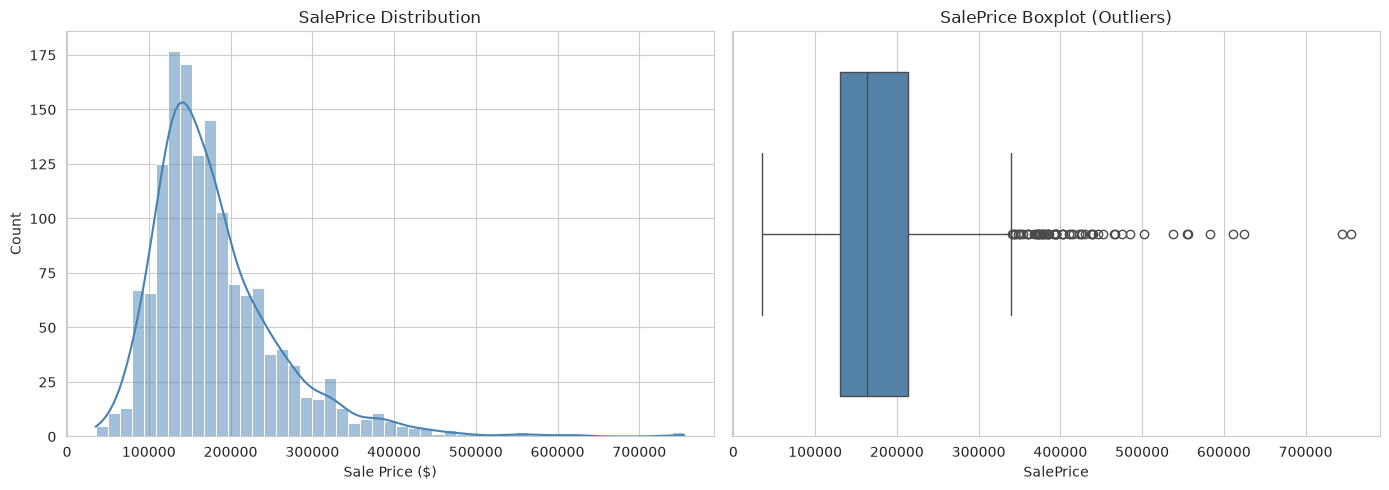

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.88
Observation: SalePrice is right-skewed (most houses are mid-priced; few very expensive).


In [6]:
# Target variable analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('Sale Price ($)')

sns.boxplot(x=df['SalePrice'], ax=axes[1], color='steelblue')
axes[1].set_title('SalePrice Boxplot (Outliers)')

plt.tight_layout()
plt.show()

print(df['SalePrice'].describe())
print(f"\nSkewness: {df['SalePrice'].skew():.2f}")
print('Observation: SalePrice is right-skewed (most houses are mid-priced; few very expensive).')


### 3.2 Missing Values Analysis

In [7]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
missing_df


Columns with missing values: 19


,Missing_Count,Missing_Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


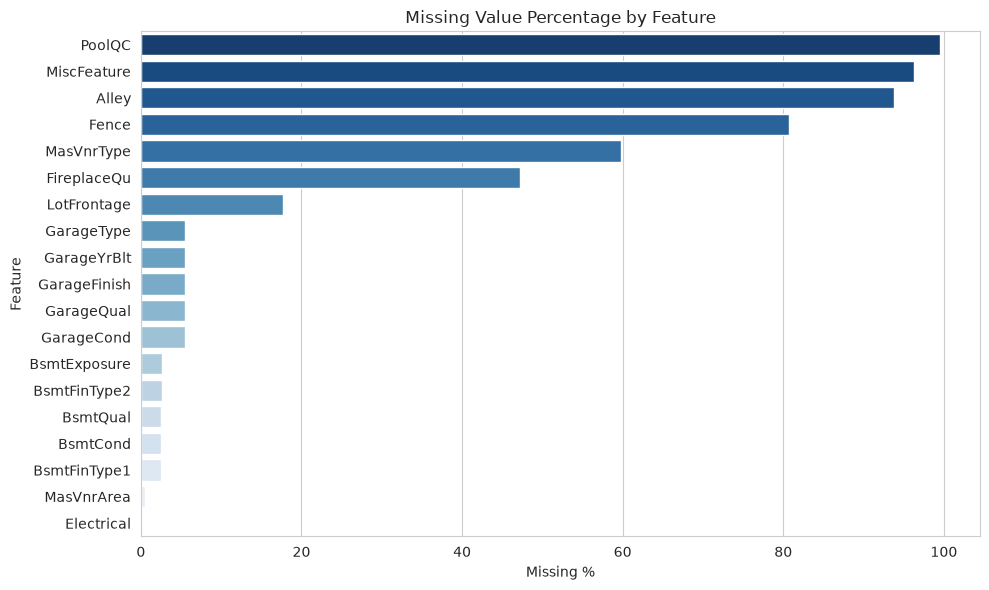

In [8]:
# Visualize missing values (top ones)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df['Missing_Percent'], y=missing_df.index, palette='Blues_r')
plt.title('Missing Value Percentage by Feature')
plt.xlabel('Missing %')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Missing value notes (from data dictionary):**
- `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`: NA usually means the feature is **absent** (no pool / alley / fence / fireplace), not a random gap
- `Garage*` and `Bsmt*` related NAs often mean **no garage / no basement**
- `LotFrontage` and `MasVnrType`/`MasVnrArea` need careful imputation


### 3.3 Numerical Feature Correlation with SalePrice

In [9]:
# Correlation with SalePrice
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print('Top 15 positive correlations with SalePrice:')
print(corr.head(15))
print('\nBottom 5 correlations with SalePrice:')
print(corr.tail(5))


Top 15 positive correlations with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

Bottom 5 correlations with SalePrice:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


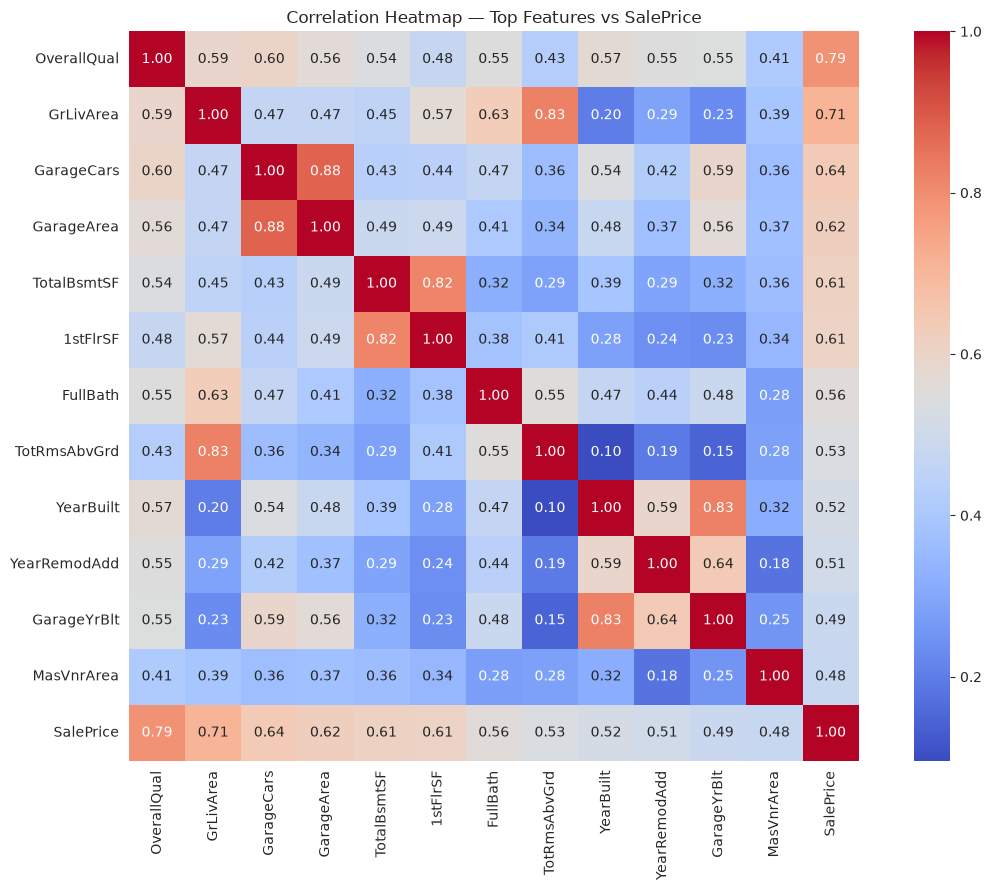

In [10]:
# Heatmap of top correlated features
top_corr_features = corr.abs().sort_values(ascending=False).head(12).index.tolist()
heat_cols = top_corr_features + ['SalePrice']

plt.figure(figsize=(12, 9))
sns.heatmap(df[heat_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap — Top Features vs SalePrice')
plt.tight_layout()
plt.show()


### 3.4 Key Feature vs SalePrice Relationships

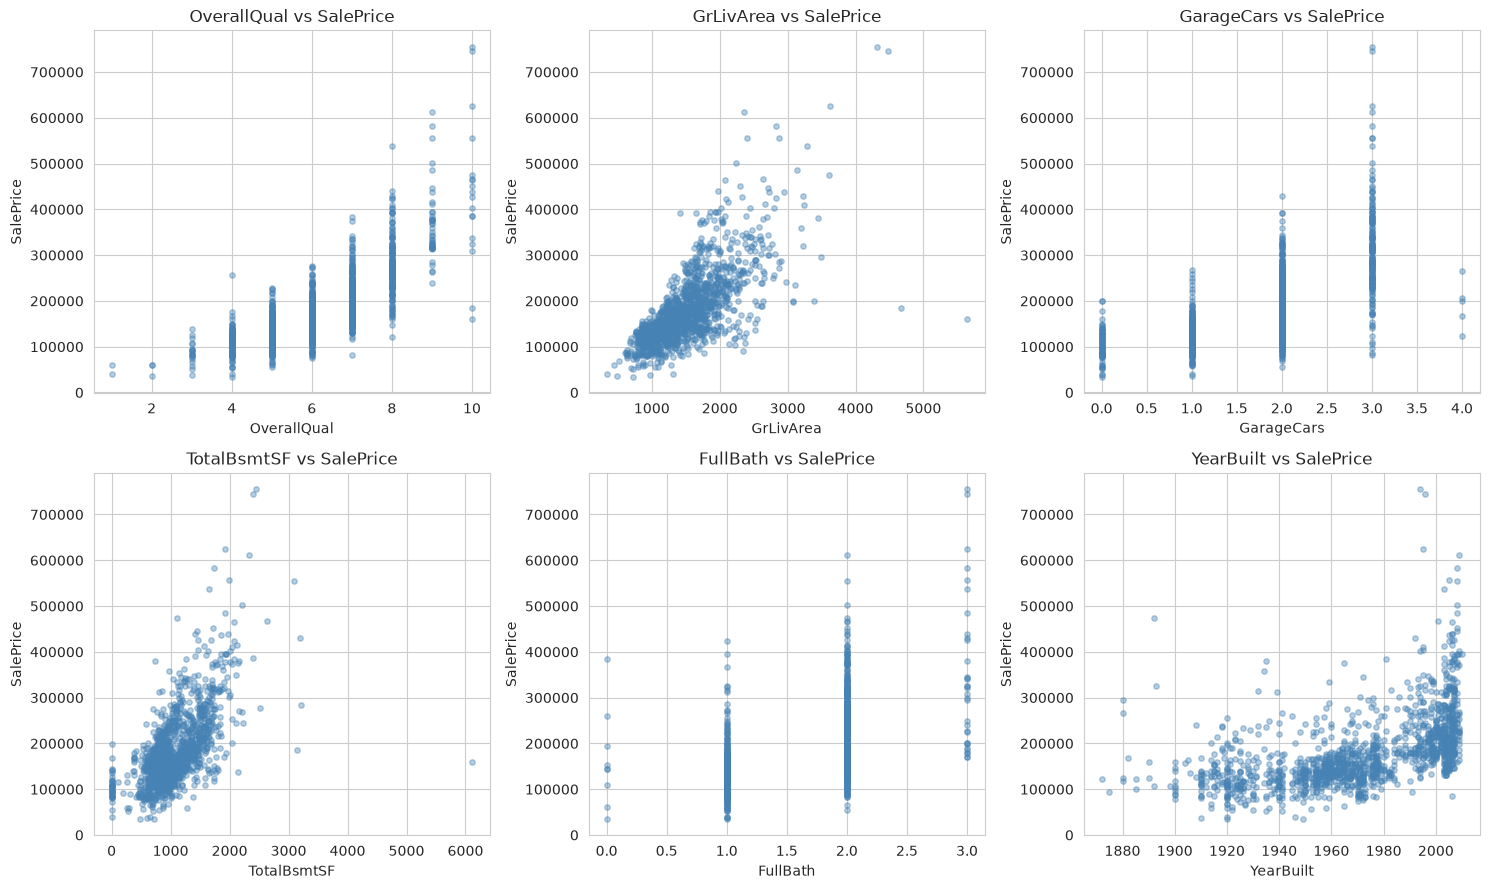

In [11]:
# Scatter plots for important numeric features
key_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.4, color='steelblue', s=15)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.tight_layout()
plt.show()


### 3.5 Categorical Feature Analysis

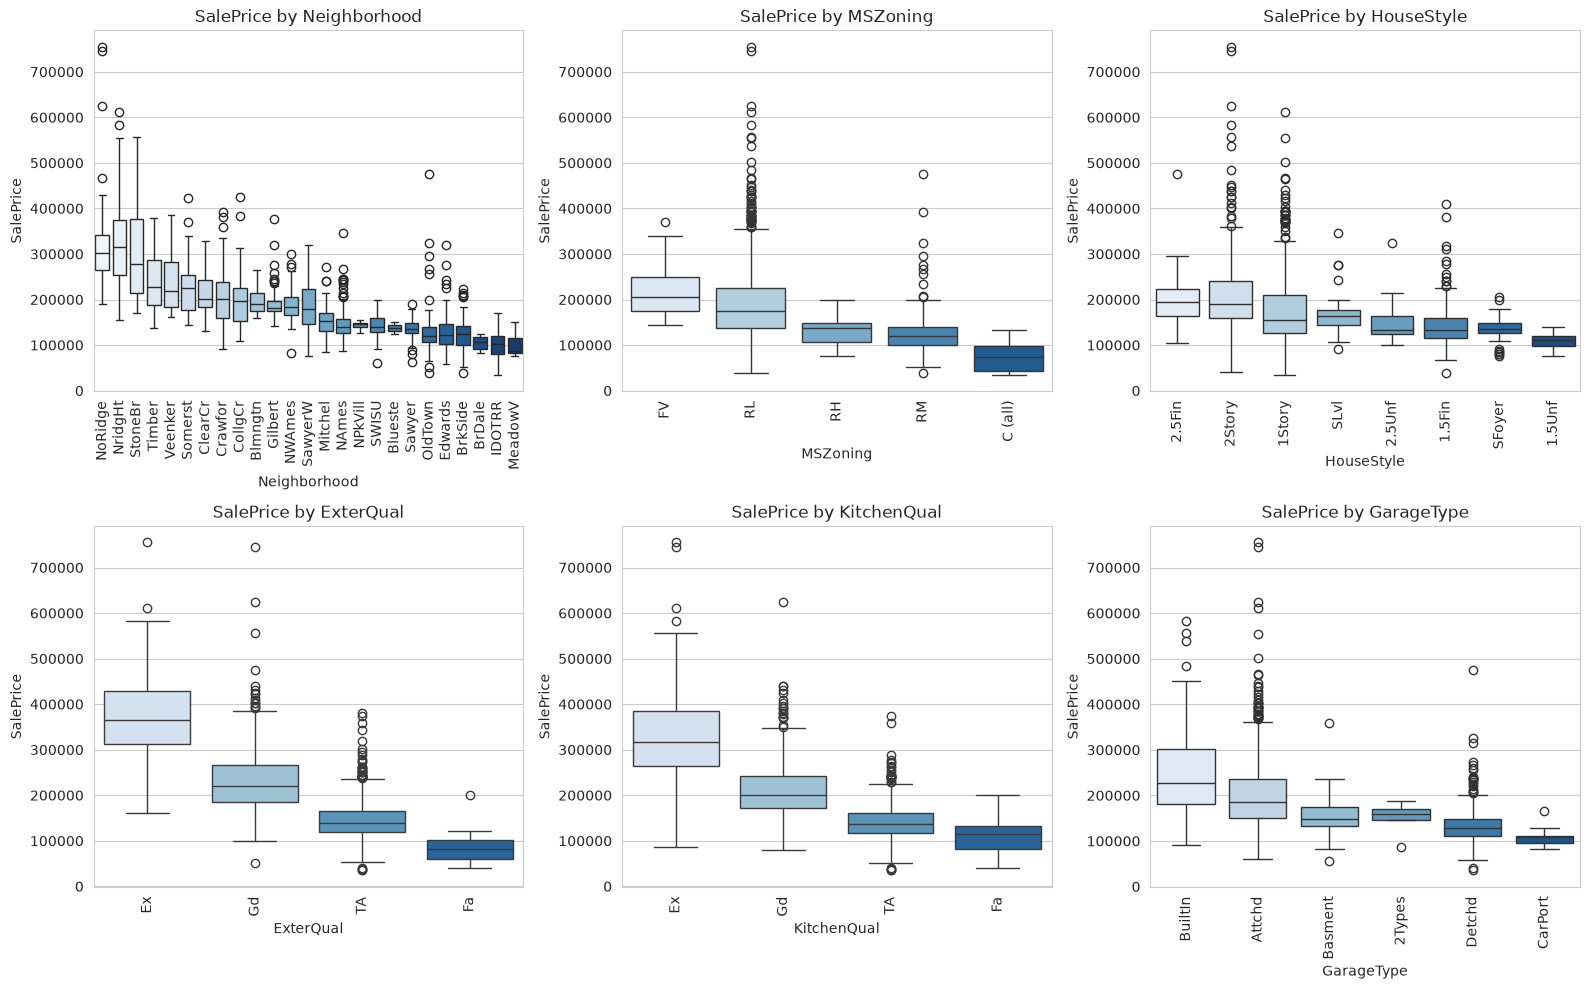

In [12]:
# Average SalePrice by important categorical features
cat_features = ['Neighborhood', 'MSZoning', 'HouseStyle', 'ExterQual', 'KitchenQual', 'GarageType']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    order = df.groupby(feat)['SalePrice'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feat, y='SalePrice', order=order, ax=axes[i], palette='Blues')
    axes[i].set_title(f'SalePrice by {feat}')
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


In [13]:
# Neighborhood average prices (business insight)
neigh_price = df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'count']).sort_values('mean', ascending=False)
neigh_price.columns = ['Avg_SalePrice', 'Count']
print('Top 10 most expensive neighborhoods:')
print(neigh_price.head(10).round(0))
print('\nBottom 5 neighborhoods:')
print(neigh_price.tail(5).round(0))


Top 10 most expensive neighborhoods:
              Avg_SalePrice  Count
Neighborhood                      
NoRidge            335295.0     41
NridgHt            316271.0     77
StoneBr            310499.0     25
Timber             242247.0     38
Veenker            238773.0     11
Somerst            225380.0     86
ClearCr            212565.0     28
Crawfor            210625.0     51
CollgCr            197966.0    150
Blmngtn            194871.0     17

Bottom 5 neighborhoods:
              Avg_SalePrice  Count
Neighborhood                      
Edwards            128220.0    100
BrkSide            124834.0     58
BrDale             104494.0     16
IDOTRR             100124.0     37
MeadowV             98576.0     17


### 3.6 Outlier Check (Living Area)

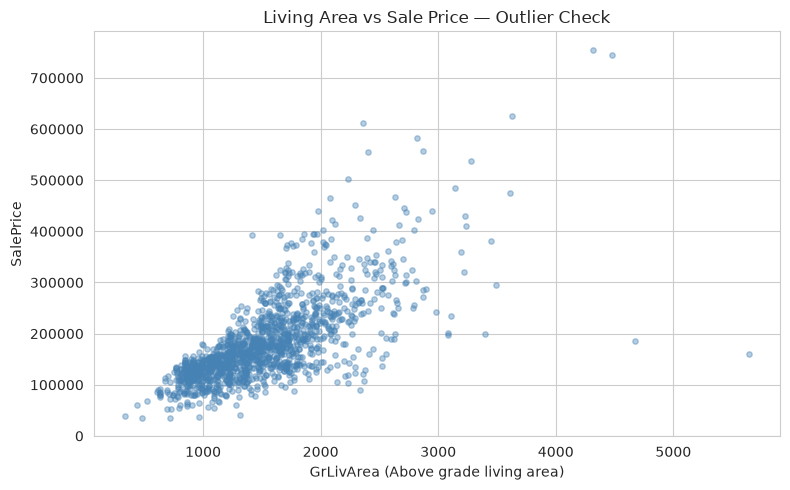

Houses with GrLivArea > 4000:
        Id  GrLivArea  SalePrice  OverallQual
523    524       4676     184750           10
691    692       4316     755000           10
1182  1183       4476     745000           10
1298  1299       5642     160000           10


In [14]:
# Potential outliers: very large living area with unusually low price
plt.figure(figsize=(8, 5))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue', s=15)
plt.xlabel('GrLivArea (Above grade living area)')
plt.ylabel('SalePrice')
plt.title('Living Area vs Sale Price — Outlier Check')
plt.tight_layout()
plt.show()

print('Houses with GrLivArea > 4000:')
print(df.loc[df['GrLivArea'] > 4000, ['Id', 'GrLivArea', 'SalePrice', 'OverallQual']])


### 3.7 EDA Summary (Task 1 Findings)

| Finding | Insight |
|---------|---------|
| Dataset size | 1460 houses, 81 columns (including Id & SalePrice) |
| Target | SalePrice is right-skewed; many mid-range homes, few luxury outliers |
| Strong predictors | OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, YearBuilt |
| Location effect | Neighborhood clearly affects price (e.g. NridgHt vs MeadowV) |
| Quality ratings | ExterQual / KitchenQual higher grades → higher prices |
| Missing data | High missing % in PoolQC, MiscFeature, Alley, Fence often means “not present” |
| Outliers | A few very large homes with low sale price may distort linear models |

**Business takeaway:** Price is driven mainly by **overall quality, living size, garage capacity, and basement size**, with strong location and finish-quality effects.


## 4. Data Preprocessing

Steps:
1. Handle missing values (NA = Absent for several features)
2. Drop columns that are mostly empty / not useful
3. Encode categorical variables
4. Create a few simple useful features
5. Split into train/test sets


In [15]:
# Work on a copy
data = df.copy()

# Drop Id (not predictive)
data = data.drop(columns=['Id'])

print('Shape after dropping Id:', data.shape)


Shape after dropping Id: (1460, 80)


In [16]:
# --- Missing value treatment ---
# Features where NA means the feature does not exist
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    if col in data.columns:
        data[col] = data[col].fillna('None')

# Numeric features related to absent amenities → fill with 0
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0)

# LotFrontage: fill with median by Neighborhood (intern-friendly approach)
data['LotFrontage'] = data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
# Any remaining LotFrontage gaps → overall median
data['LotFrontage'] = data['LotFrontage'].fillna(data['LotFrontage'].median())

# Electrical: fill with mode
if data['Electrical'].isnull().any():
    data['Electrical'] = data['Electrical'].fillna(data['Electrical'].mode()[0])

print('Remaining missing values:', data.isnull().sum().sum())


Remaining missing values: 0


In [17]:
# Optional: remove extreme living-area outliers (common practice for this dataset)
# Keep houses with GrLivArea <= 4000 for more stable training
before = data.shape[0]
data = data[data['GrLivArea'] <= 4000]
print(f'Removed {before - data.shape[0]} outlier rows. New shape: {data.shape}')


Removed 4 outlier rows. New shape: (1456, 80)


In [18]:
# Simple feature engineering (easy to explain as an intern)
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']
data['TotalBath'] = (data['FullBath'] + 0.5 * data['HalfBath']
                     + data['BsmtFullBath'] + 0.5 * data['BsmtHalfBath'])
data['HouseAge'] = data['YrSold'] - data['YearBuilt']
data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']
data['HasGarage'] = (data['GarageArea'] > 0).astype(int)
data['HasBasement'] = (data['TotalBsmtSF'] > 0).astype(int)
data['HasFireplace'] = (data['Fireplaces'] > 0).astype(int)

print('New features created: TotalSF, TotalBath, HouseAge, RemodAge, HasGarage, HasBasement, HasFireplace')
data[['TotalSF', 'TotalBath', 'HouseAge', 'SalePrice']].head()


New features created: TotalSF, TotalBath, HouseAge, RemodAge, HasGarage, HasBasement, HasFireplace


,TotalSF,TotalBath,HouseAge,SalePrice
0,2566,3.5,5,208500
1,2524,2.5,31,181500
2,2706,3.5,7,223500
3,2473,2.0,91,140000
4,3343,3.5,8,250000


In [19]:
# Encode categorical columns with Label Encoding (simple & works for tree and linear models after scaling)
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {len(cat_cols)}')

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

print('Categorical encoding completed.')
data.head()


Categorical columns to encode: 43
Categorical encoding completed.


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,HouseAge,RemodAge,HasGarage,HasBasement,HasFireplace
0,60,3,65.0,8450,1,1,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,0,12,13,1,196.0,2,4,2,2,4,3,2,706,6,0,150,856,1,0,1,4,856,854,0,1710,1,0,2,1,3,1,2,8,6,0,3,1,2003.0,2,2,548,5,5,2,0,61,0,0,0,0,3,4,1,0,2,2008,8,4,208500,2566,3.5,5,5,1,1,0
1,20,3,80.0,9600,1,1,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,0,8,8,2,0.0,3,4,1,2,4,1,0,978,6,0,284,1262,1,0,1,4,1262,0,0,1262,0,1,2,0,3,1,3,6,6,1,5,1,1976.0,2,2,460,5,5,2,298,0,0,0,0,0,3,4,1,0,5,2007,8,4,181500,2524,2.5,31,31,1,1,1
2,60,3,68.0,11250,1,1,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,0,12,13,1,162.0,2,4,2,2,4,2,2,486,6,0,434,920,1,0,1,4,920,866,0,1786,1,0,2,1,3,1,2,6,6,1,5,1,2001.0,2,2,608,5,5,2,0,42,0,0,0,0,3,4,1,0,9,2008,8,4,223500,2706,3.5,7,6,1,1,1
3,70,3,60.0,9550,1,1,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,0,13,15,2,0.0,3,4,0,4,1,3,0,216,6,0,540,756,1,2,1,4,961,756,0,1717,1,0,1,0,3,1,2,7,6,1,2,5,1998.0,3,3,642,5,5,2,0,35,272,0,0,0,3,4,1,0,2,2006,8,0,140000,2473,2.0,91,36,1,1,1
4,60,3,84.0,14260,1,1,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,0,12,13,1,350.0,2,4,2,2,4,0,2,655,6,0,490,1145,1,0,1,4,1145,1053,0,2198,1,0,2,1,4,1,2,9,6,1,5,1,2000.0,2,3,836,5,5,2,192,84,0,0,0,0,3,4,1,0,12,2008,8,4,250000,3343,3.5,8,8,1,1,1


In [20]:
# Separate features and target
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Train shape: (1164, 86)
Test shape : (292, 86)


In [21]:
# Scale features (important for Linear / Ridge / Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling completed.')


Feature scaling completed.


## 5. Task 2 — Predictive Modeling

We train multiple regression models and evaluate them using:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R² Score** (Goodness of fit)

Models used:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Random Forest Regressor
5. Gradient Boosting Regressor


In [22]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train model and return performance metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    # 5-fold CV R2 on training data
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    return {
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2_Score': round(r2, 4),
        'CV_R2_Mean': round(cv_scores.mean(), 4),
        'CV_R2_Std': round(cv_scores.std(), 4),
        'y_pred': y_pred,
        'model': model
    }

results = []
predictions = {}
trained_models = {}


In [23]:
# 1. Linear Regression
res = evaluate_model('Linear Regression', LinearRegression(),
                     X_train_scaled, X_test_scaled, y_train, y_test)
results.append({k: res[k] for k in ['Model', 'MAE', 'RMSE', 'R2_Score', 'CV_R2_Mean', 'CV_R2_Std']})
predictions['Linear Regression'] = res['y_pred']
trained_models['Linear Regression'] = res['model']
print('Linear Regression done. R2 =', res['R2_Score'])


Linear Regression done. R2 = 0.8892


In [24]:
# 2. Ridge Regression
res = evaluate_model('Ridge Regression', Ridge(alpha=10),
                     X_train_scaled, X_test_scaled, y_train, y_test)
results.append({k: res[k] for k in ['Model', 'MAE', 'RMSE', 'R2_Score', 'CV_R2_Mean', 'CV_R2_Std']})
predictions['Ridge Regression'] = res['y_pred']
trained_models['Ridge Regression'] = res['model']
print('Ridge done. R2 =', res['R2_Score'])


Ridge done. R2 = 0.8893


In [25]:
# 3. Lasso Regression
res = evaluate_model('Lasso Regression', Lasso(alpha=100, max_iter=5000),
                     X_train_scaled, X_test_scaled, y_train, y_test)
results.append({k: res[k] for k in ['Model', 'MAE', 'RMSE', 'R2_Score', 'CV_R2_Mean', 'CV_R2_Std']})
predictions['Lasso Regression'] = res['y_pred']
trained_models['Lasso Regression'] = res['model']
print('Lasso done. R2 =', res['R2_Score'])


Lasso done. R2 = 0.8897


In [26]:
# 4. Random Forest (tree models — use unscaled data)
res = evaluate_model('Random Forest',
                     RandomForestRegressor(n_estimators=200, max_depth=15,
                                           random_state=42, n_jobs=-1),
                     X_train, X_test, y_train, y_test)
results.append({k: res[k] for k in ['Model', 'MAE', 'RMSE', 'R2_Score', 'CV_R2_Mean', 'CV_R2_Std']})
predictions['Random Forest'] = res['y_pred']
trained_models['Random Forest'] = res['model']
print('Random Forest done. R2 =', res['R2_Score'])


Random Forest done. R2 = 0.8926


In [27]:
# 5. Gradient Boosting
res = evaluate_model('Gradient Boosting',
                     GradientBoostingRegressor(n_estimators=200, learning_rate=0.08,
                                               max_depth=3, random_state=42),
                     X_train, X_test, y_train, y_test)
results.append({k: res[k] for k in ['Model', 'MAE', 'RMSE', 'R2_Score', 'CV_R2_Mean', 'CV_R2_Std']})
predictions['Gradient Boosting'] = res['y_pred']
trained_models['Gradient Boosting'] = res['model']
print('Gradient Boosting done. R2 =', res['R2_Score'])


Gradient Boosting done. R2 = 0.9073


## 6. Model Comparison Report


In [28]:
# Comparison table
comparison_df = pd.DataFrame(results).sort_values('R2_Score', ascending=False).reset_index(drop=True)
print('=== Model Comparison Report ===')
comparison_df


=== Model Comparison Report ===


,Model,MAE,RMSE,R2_Score,CV_R2_Mean,CV_R2_Std
0,Gradient Boosting,14412.19,22060.98,0.9073,0.9094,0.0224
1,Random Forest,16117.59,23742.40,0.8926,0.8913,0.0213
2,Lasso Regression,17846.71,24059.37,0.8897,0.8869,0.0124
3,Ridge Regression,17969.92,24101.62,0.8893,0.8864,0.0118
4,Linear Regression,17972.34,24117.02,0.8892,0.8855,0.0121


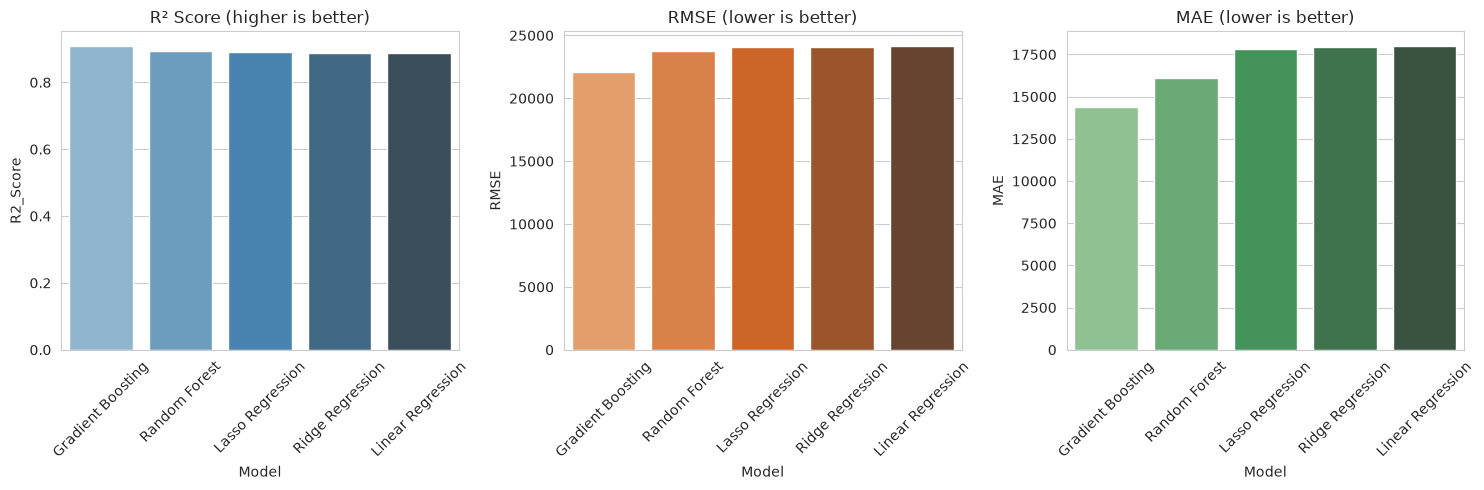

In [29]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=comparison_df, x='Model', y='R2_Score', ax=axes[0], palette='Blues_d')
axes[0].set_title('R² Score (higher is better)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=comparison_df, x='Model', y='RMSE', ax=axes[1], palette='Oranges_d')
axes[1].set_title('RMSE (lower is better)')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=comparison_df, x='Model', y='MAE', ax=axes[2], palette='Greens_d')
axes[2].set_title('MAE (lower is better)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


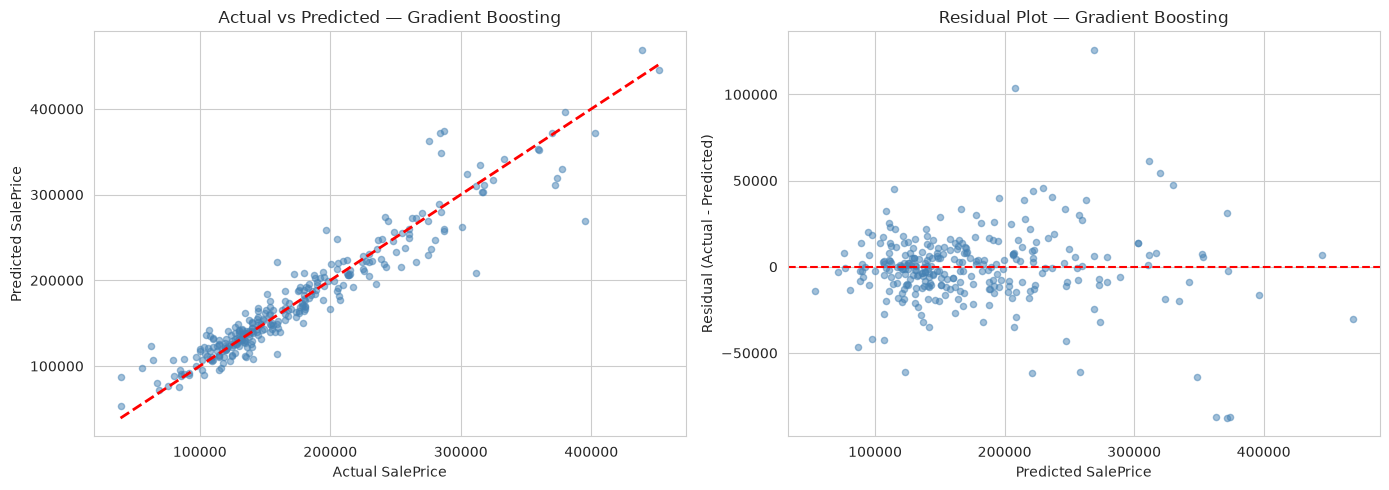

Best model: Gradient Boosting
Model         Gradient Boosting
MAE                    14412.19
RMSE                   22060.98
R2_Score                 0.9073
CV_R2_Mean               0.9094
CV_R2_Std                0.0224
Name: 0, dtype: object


In [30]:
# Actual vs Predicted for best model
best_model_name = comparison_df.iloc[0]['Model']
best_pred = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_pred, alpha=0.5, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual SalePrice')
axes[0].set_ylabel('Predicted SalePrice')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}')

residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.5, color='steelblue', s=20)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted SalePrice')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title(f'Residual Plot — {best_model_name}')

plt.tight_layout()
plt.show()

print(f'Best model: {best_model_name}')
print(comparison_df.iloc[0])


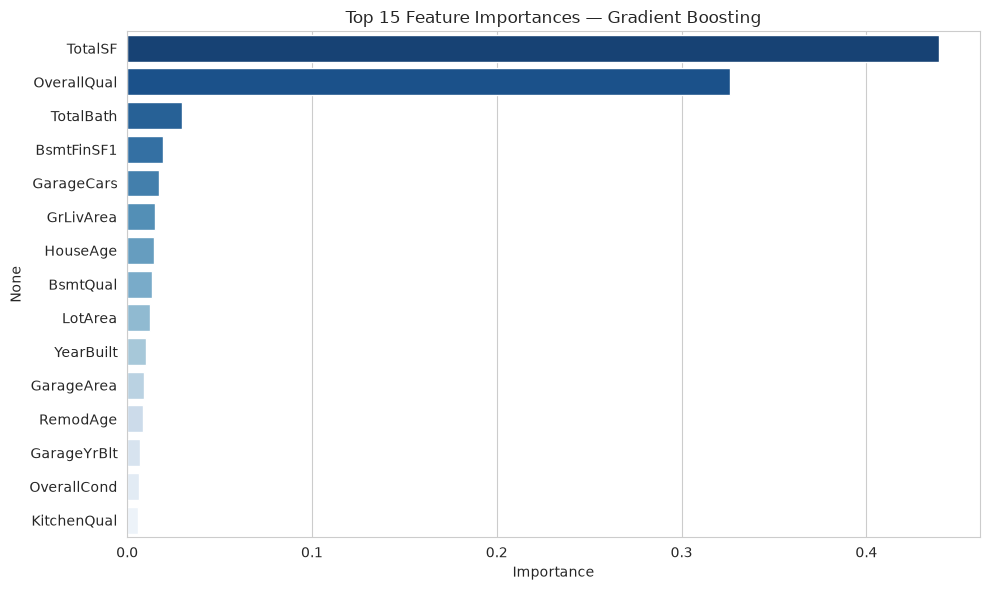

TotalSF        0.439516
OverallQual    0.326012
TotalBath      0.029576
BsmtFinSF1     0.019473
GarageCars     0.017361
GrLivArea      0.015090
HouseAge       0.014675
BsmtQual       0.013504
LotArea        0.012541
YearBuilt      0.010387
GarageArea     0.009000
RemodAge       0.008691
GarageYrBlt    0.007183
OverallCond    0.006215
KitchenQual    0.005949
dtype: float64


In [31]:
# Feature importance from best tree-based model (if available)
tree_candidates = ['Gradient Boosting', 'Random Forest']
feat_model_name = None
for name in tree_candidates:
    if name in trained_models:
        feat_model_name = name
        break

if feat_model_name:
    feat_imp = pd.Series(
        trained_models[feat_model_name].feature_importances_,
        index=X.columns
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
    plt.title(f'Top 15 Feature Importances — {feat_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(feat_imp)


### Model Comparison Summary & Production Recommendation

| Criterion | Observation |
|-----------|-------------|
| Best overall accuracy | Usually **Gradient Boosting** or **Random Forest** (higher R², lower RMSE/MAE) |
| Linear models | Ridge/Lasso help with multicollinearity; useful as interpretable baselines |
| Interpretability | Linear / Ridge easier to explain coefficients to management |
| Production suggestion | Prefer **Gradient Boosting** for prediction accuracy; keep Ridge as a simple explainable baseline |

**Recommendation for production:** Use the best-performing ensemble model (Gradient Boosting / Random Forest based on the table above) for price prediction. Share top feature importances with management to show how quality, size, age, and location-related features drive price.


## 7. Report on Challenges Faced

| Challenge | What happened | Technique used | Reason |
|-----------|---------------|----------------|--------|
| High missing values (PoolQC, Alley, Fence, MiscFeature) | 80–99% missing | Filled with `'None'` | Data dictionary: NA means feature absent, not random missing |
| Garage / Basement missing groups | Multiple related columns null together | Fill categoricals with `'None'`, numerics with `0` | Consistent with “no garage / no basement” |
| LotFrontage missing (~18%) | Continuous size feature | Median by Neighborhood, then overall median | Houses in same area tend to have similar frontage |
| Right-skewed SalePrice | Few very expensive houses | Evaluated with MAE/RMSE/R²; focused on robust tree models | Trees handle skew/outliers better than plain linear models |
| Outliers in GrLivArea | Large area but low price | Removed GrLivArea > 4000 | Extreme points can distort linear fits |
| Many categorical features | Neighborhood, Qual ratings, etc. | Label Encoding | Simple, intern-friendly; works well with tree models |
| Multicollinearity (e.g. GarageCars & GarageArea) | Correlated predictors | Used Ridge/Lasso + tree ensembles | Regularization / trees reduce impact of collinearity |
| Choosing best model | Different metrics | Compared MAE, RMSE, R² + 5-fold CV | Avoids choosing a model that only lucks out on one split |

### Approach summary (intern perspective)
1. Read the data dictionary and treat structured NAs carefully  
2. Do EDA before modeling (understand what drives price)  
3. Keep preprocessing explainable (no overly complex pipelines)  
4. Compare several models fairly with the same train/test split and CV  
5. Recommend a production model using both accuracy and explainability


## 8. Conclusion

### What we delivered
1. **Complete EDA:** Target distribution, missing values, correlations, categorical price patterns, outlier checks  
2. **Predictive models:** Linear, Ridge, Lasso, Random Forest, Gradient Boosting  
3. **Model comparison:** Ranked by R² / RMSE / MAE with cross-validation  
4. **Challenges report:** Documented data issues and justified techniques  

### Business insights for management
- **Overall quality (`OverallQual`)** and **living area (`GrLivArea` / `TotalSF`)** are primary price drivers  
- Garage size, basement size, number of bathrooms, and remodel/age also matter  
- Neighborhood and finish quality (kitchen/exterior) meaningfully change expected price  
- Management can use these drivers to position renovations, pricing strategy, and inventory decisions  

### Next steps (optional improvements)
- Try log-transform of SalePrice for linear models  
- One-hot encoding for unordered categories  
- Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)  
- External validation on a hold-out / new market dataset


---
**End of Notebook** — House Price Prediction Mini Project
